<a href="https://colab.research.google.com/github/shankar27git/Spectral-Alignment-in-QML/blob/main/Spectral_Alignment_in_QML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

import yfinance as yf
import pandas as pd

tickers = ["AAPL", "AMZN", "GOOGL", "META", "NFLX"]

data = yf.download(tickers, start="2015-01-01", end="2024-12-31")
data.head()


/tmp/ipython-input-470926208.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2015-01-01", end="2024-12-31")
[*********************100%***********************]  5 of 5 completed


Price           Close                                                High  \
Ticker           AAPL     AMZN      GOOGL       META      NFLX       AAPL   
Date                                                                        
2015-01-02  24.214893  15.4260  26.278942  77.905800  4.984857  24.682226   
2015-01-05  23.532721  15.1095  25.778227  76.654556  4.731143  24.064284   
2015-01-06  23.534939  14.7645  25.142035  75.621758  4.650143  23.794075   
2015-01-07  23.864944  14.9210  25.068096  75.621758  4.674286  23.964612   
2015-01-08  24.781885  15.0230  25.155432  77.637672  4.778000  24.839472   

Price                                                ...       Open           \
Ticker         AMZN      GOOGL       META      NFLX  ...       AAPL     AMZN   
Date                                                 ...                       
2015-01-02  15.7375  26.589099  78.382474  5.033143  ...  24.671151  15.6290   
2015-01-05  15.4190  26.201529  78.700264  4.925857  ...  23.984549  15.3505   
2015-01-06  15.1500  25.865070  77.051763  4.764000  ...  23.596954  15.1120   
2015-01-07  15.0640  25.382718  76.823363  4.742143  ...  23.743127  14.8750   
2015-01-08  15.1570  25.184710  77.687329  4.783571  ...  24.192738  15.0160   

Price                                          Volume                      \
Ticker          GOOGL       META      NFLX       AAPL      AMZN     GOOGL   
Date                                                                        
2015-01-02  26.430297  78.034903  4.915143  212818400  55664000  26480000   
2015-01-05  26.159844  77.439077  4.925857  257142000  55484000  41182000   
2015-01-06  25.829837  76.694267  4.734714  263188400  70380000  54456000   
2015-01-07  25.355922  76.227527  4.734714  160423600  52806000  46918000   
2015-01-08  24.887456  76.207659  4.712000  237458000  61768000  73054000   

Price                            
Ticker          META       NFLX  
Date                             
2015-01-02  18177500  134750000  
2015-01-05  26452200  181650000  
2015-01-06  27399300  160377000  
2015-01-07  22045300   98497000  
2015-01-08  23961000   96019000  

[5 rows x 25 columns]

In [ ]:
!pip install yfinance ta

import yfinance as yf
import pandas as pd
import numpy as np

# FAANG tickers (META instead of FB)
tickers = ["AAPL", "AMZN", "GOOGL", "META", "NFLX"]

data = yf.download(tickers, start="2015-01-01", end="2024-12-31", group_by='ticker')

data.head()


  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=d9058db55b1efd72e1947a91d7f94eed3c70a0b9dd5e061d0c7079d41eb79b2f
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


/tmp/ipython-input-2637292990.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2015-01-01", end="2024-12-31", group_by='ticker')
[*********************100%***********************]  5 of 5 completed


Ticker           AAPL                                                  GOOGL  \
Price            Open       High        Low      Close     Volume       Open   
Date                                                                           
2015-01-02  24.671151  24.682226  23.776353  24.214893  212818400  26.430297   
2015-01-05  23.984549  24.064284  23.346674  23.532721  257142000  26.159844   
2015-01-06  23.596954  23.794075  23.173918  23.534939  263188400  25.829837   
2015-01-07  23.743127  23.964612  23.632385  23.864944  160423600  25.355922   
2015-01-08  24.192738  24.839472  24.075349  24.781885  237458000  24.887456   

Ticker                                                 ...       META  \
Price            High        Low      Close    Volume  ...       Open   
Date                                                   ...              
2015-01-02  26.589099  26.196066  26.278942  26480000  ...  78.034903   
2015-01-05  26.201529  25.693369  25.778227  41182000  ...  77.439077   
2015-01-06  25.865070  25.087943  25.142035  54456000  ...  76.694267   
2015-01-07  25.382718  24.993660  25.068096  46918000  ...  76.227527   
2015-01-08  25.184710  24.565388  25.155432  73054000  ...  76.207659   

Ticker                                                     NFLX            \
Price            High        Low      Close    Volume      Open      High   
Date                                                                        
2015-01-02  78.382474  77.161003  77.905800  18177500  4.915143  5.033143   
2015-01-05  78.700264  76.326844  76.654556  26452200  4.925857  4.925857   
2015-01-06  77.051763  74.837237  75.621758  27399300  4.734714  4.764000   
2015-01-07  76.823363  75.294045  75.621758  22045300  4.734714  4.742143   
2015-01-08  77.687329  75.552241  77.637672  23961000  4.712000  4.783571   

Ticker                                     
Price            Low     Close     Volume  
Date                                       
2015-01-02  4.873143  4.984857  134750000  
2015-01-05  4.714714  4.731143  181650000  
2015-01-06  4.566143  4.650143  160377000  
2015-01-07  4.627143  4.674286   98497000  
2015-01-08  4.647857  4.778000   96019000  

[5 rows x 25 columns]

In [ ]:
dfs = []

for ticker in tickers:
    df = data[ticker].copy()
    df["Ticker"] = ticker
    df.reset_index(inplace=True)
    dfs.append(df)

df = pd.concat(dfs)
df.head()


Price,Date,Open,High,Low,Close,Volume,Ticker
0,2015-01-02,24.671151,24.682226,23.776353,24.214893,212818400,AAPL
1,2015-01-05,23.984549,24.064284,23.346674,23.532721,257142000,AAPL
2,2015-01-06,23.596954,23.794075,23.173918,23.534939,263188400,AAPL
3,2015-01-07,23.743127,23.964612,23.632385,23.864944,160423600,AAPL
4,2015-01-08,24.192738,24.839472,24.075349,24.781885,237458000,AAPL


In [ ]:
import ta

def add_indicators(df):
    df["RSI"] = ta.momentum.RSIIndicator(df["Close"]).rsi()
    df["SMA_20"] = ta.trend.SMAIndicator(df["Close"], window=20).sma_indicator()
    df["EMA_20"] = ta.trend.EMAIndicator(df["Close"], window=20).ema_indicator()

    macd = ta.trend.MACD(df["Close"])
    df["MACD"] = macd.macd()
    df["MACD_signal"] = macd.macd_signal()

    bb = ta.volatility.BollingerBands(df["Close"])
    df["BB_high"] = bb.bollinger_hband()
    df["BB_low"] = bb.bollinger_lband()

    return df

df = df.groupby("Ticker").apply(add_indicators).reset_index(drop=True)

df.head()


/tmp/ipython-input-1721807792.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Ticker").apply(add_indicators).reset_index(drop=True)


Price,Date,Open,High,Low,Close,Volume,Ticker,RSI,SMA_20,EMA_20,MACD,MACD_signal,BB_high,BB_low
0,2015-01-02,24.671151,24.682226,23.776353,24.214893,212818400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,23.984549,24.064284,23.346674,23.532721,257142000,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-06,23.596954,23.794075,23.173918,23.534939,263188400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-07,23.743127,23.964612,23.632385,23.864944,160423600,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-08,24.192738,24.839472,24.075349,24.781885,237458000,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import ta

def add_indicators(df):
    df["RSI"] = ta.momentum.RSIIndicator(df["Close"]).rsi()
    df["SMA_20"] = ta.trend.SMAIndicator(df["Close"], window=20).sma_indicator()
    df["EMA_20"] = ta.trend.EMAIndicator(df["Close"], window=20).ema_indicator()

    macd = ta.trend.MACD(df["Close"])
    df["MACD"] = macd.macd()
    df["MACD_signal"] = macd.macd_signal()

    bb = ta.volatility.BollingerBands(df["Close"])
    df["BB_high"] = bb.bollinger_hband()
    df["BB_low"] = bb.bollinger_lband()

    return df

df = df.groupby("Ticker").apply(add_indicators).reset_index(drop=True)

df.head()


/tmp/ipython-input-1721807792.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Ticker").apply(add_indicators).reset_index(drop=True)


Price,Date,Open,High,Low,Close,Volume,Ticker,RSI,SMA_20,EMA_20,MACD,MACD_signal,BB_high,BB_low
0,2015-01-02,24.671151,24.682226,23.776353,24.214893,212818400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,23.984549,24.064284,23.346674,23.532721,257142000,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-06,23.596954,23.794075,23.173918,23.534939,263188400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-07,23.743127,23.964612,23.632385,23.864944,160423600,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-08,24.192738,24.839472,24.075349,24.781885,237458000,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df["Future_Close"] = df.groupby("Ticker")["Close"].shift(-1)
df["Target"] = (df["Future_Close"] > df["Close"]).astype(int)

df = df.dropna()

df[["Close", "Future_Close", "Target"]].head()


Price,Close,Future_Close,Target
33,28.795427,29.573692,1
34,29.573692,29.389143,0
35,29.389143,28.637550,0
36,28.637550,29.000006,1
37,29.000006,28.564180,0


In [ ]:
from sklearn.model_selection import train_test_split

features = [
    "RSI", "SMA_20", "EMA_20",
    "MACD", "MACD_signal",
    "BB_high", "BB_low", "Volume"
]

X = df[features]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))


Accuracy: 0.5203546956872229
              precision    recall  f1-score   support

           0       0.52      0.39      0.45      1221
           1       0.52      0.64      0.58      1260

    accuracy                           0.52      2481
   macro avg       0.52      0.52      0.51      2481
weighted avg       0.52      0.52      0.51      2481



In [ ]:
from sklearn.model_selection import train_test_split

features = [
    "RSI", "SMA_20", "EMA_20",
    "MACD", "MACD_signal",
    "BB_high", "BB_low", "Volume"
]

X = df[features]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))


Accuracy: 0.5203546956872229
              precision    recall  f1-score   support

           0       0.52      0.39      0.45      1221
           1       0.52      0.64      0.58      1260

    accuracy                           0.52      2481
   macro avg       0.52      0.52      0.51      2481
weighted avg       0.52      0.52      0.51      2481



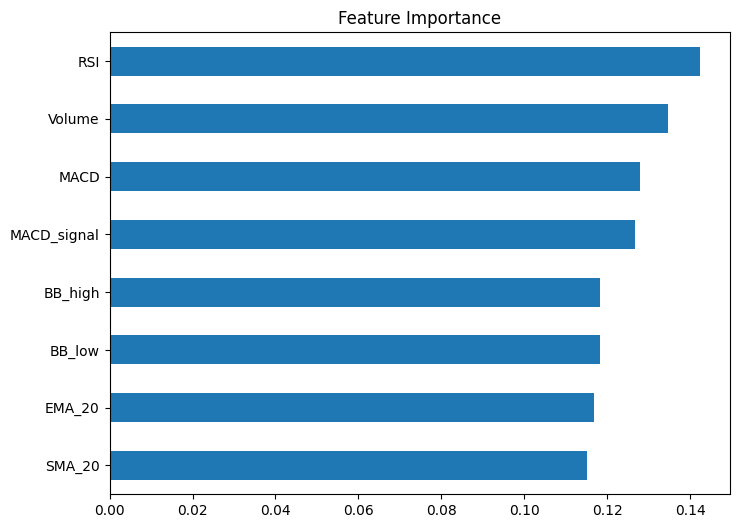

In [ ]:
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance")
plt.show()


In [ ]:
df_test = df.iloc[-len(y_test):].copy()
df_test["Prediction"] = preds

# Strategy Return
df_test["Market_Return"] = df_test["Close"].pct_change()
df_test["Strategy_Return"] = df_test["Market_Return"] * df_test["Prediction"]

df_test.head()


Price,Date,Open,High,Low,Close,Volume,Ticker,RSI,SMA_20,EMA_20,MACD,MACD_signal,BB_high,BB_low,Future_Close,Target,Prediction,Market_Return,Strategy_Return
10093,2015-02-20,6.795000,6.837429,6.763714,6.831429,94220000,NFLX,79.919089,6.484843,6.364119,0.355085,0.361841,6.835925,6.133761,6.740571,0,0,NaN,NaN
10094,2015-02-23,6.830000,6.831429,6.714286,6.740571,90314000,NFLX,73.609596,6.509400,6.399972,0.342036,0.357880,6.859888,6.158912,6.784000,1,0,-0.013300,-0.0
10095,2015-02-24,6.737286,6.808429,6.735571,6.784000,60753000,NFLX,74.640196,6.529629,6.436546,0.331378,0.352580,6.894193,6.165064,6.833286,1,0,0.006443,0.0
10096,2015-02-25,6.780714,6.879429,6.780714,6.833286,68544000,NFLX,75.795431,6.546886,6.474331,0.323184,0.346701,6.933943,6.159828,6.900429,1,0,0.007265,0.0
10097,2015-02-26,6.862571,6.950000,6.843000,6.900429,108528000,NFLX,77.311740,6.575864,6.514911,0.318436,0.341048,6.977405,6.174323,6.784429,0,0,0.009826,0.0


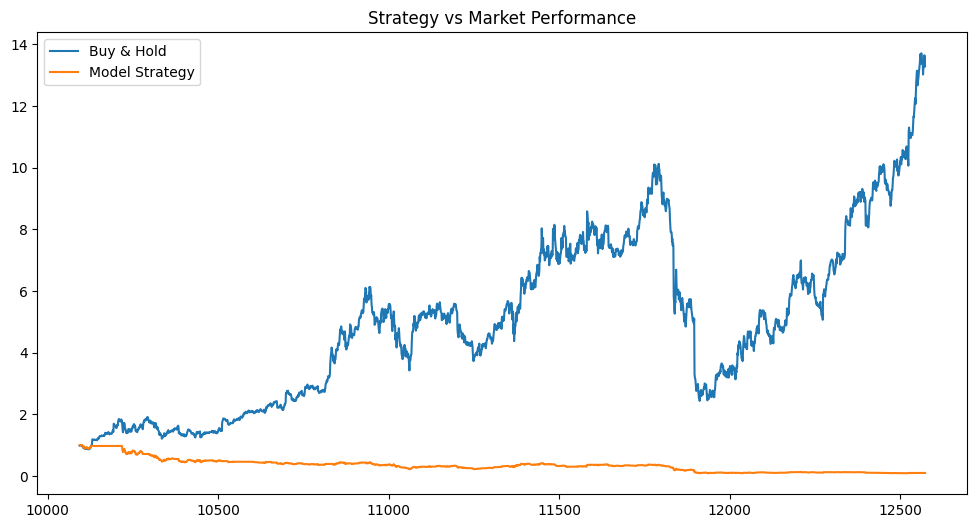

In [ ]:
df_test["Cumulative_Market"] = (1 + df_test["Market_Return"]).cumprod()
df_test["Cumulative_Strategy"] = (1 + df_test["Strategy_Return"]).cumprod()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df_test["Cumulative_Market"], label="Buy & Hold")
plt.plot(df_test["Cumulative_Strategy"], label="Model Strategy")
plt.legend()
plt.title("Strategy vs Market Performance")
plt.show()


In [ ]:
# Sharpe Ratio
sharpe = df_test["Strategy_Return"].mean() / df_test["Strategy_Return"].std()
print("Sharpe Ratio:", sharpe)

# Max Drawdown
cum_returns = df_test["Cumulative_Strategy"]
rolling_max = cum_returns.cummax()
drawdown = cum_returns / rolling_max - 1
max_drawdown = drawdown.min()

print("Max Drawdown:", max_drawdown)


Sharpe Ratio: -0.029177924594654743
Max Drawdown: -0.9109865268603814


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Use the same feature list
features = [
    "RSI", "SMA_20", "EMA_20",
    "MACD", "MACD_signal",
    "BB_high", "BB_low", "Volume"
]

X_features = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

X_scaled.shape


(12405, 8)

In [ ]:
# Covariance matrix
cov_matrix = np.cov(X_scaled, rowvar=False)

cov_matrix.shape


(8, 8)

In [ ]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

eigenvalues


array([ 4.45913284e+00,  2.11893659e+00,  8.55650492e-01,  5.26230921e-01,
        3.48981735e-02,  5.74954296e-03,  4.63944216e-05, -5.69748242e-17])

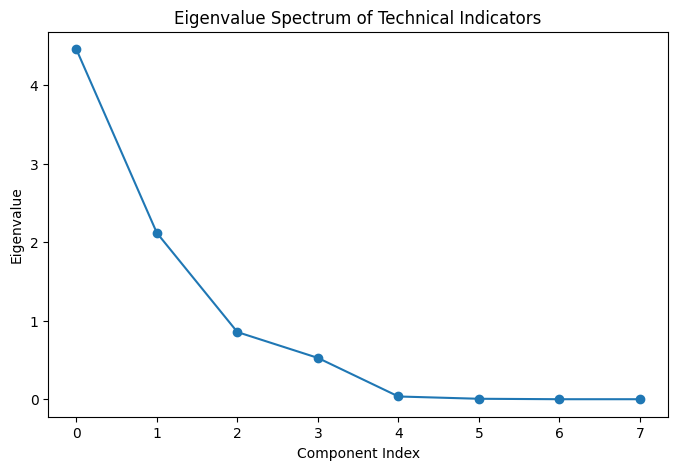

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(eigenvalues, marker='o')
plt.title("Eigenvalue Spectrum of Technical Indicators")
plt.xlabel("Component Index")
plt.ylabel("Eigenvalue")
plt.show()


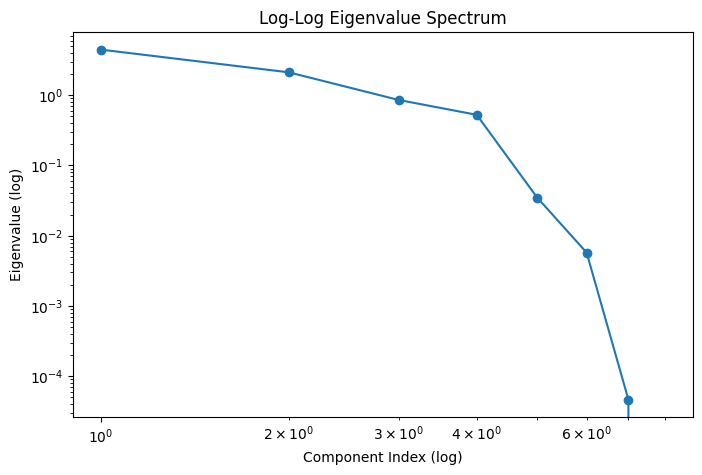

In [ ]:
plt.figure(figsize=(8,5))
plt.loglog(range(1, len(eigenvalues)+1), eigenvalues, marker='o')
plt.title("Log-Log Eigenvalue Spectrum")
plt.xlabel("Component Index (log)")
plt.ylabel("Eigenvalue (log)")
plt.show()


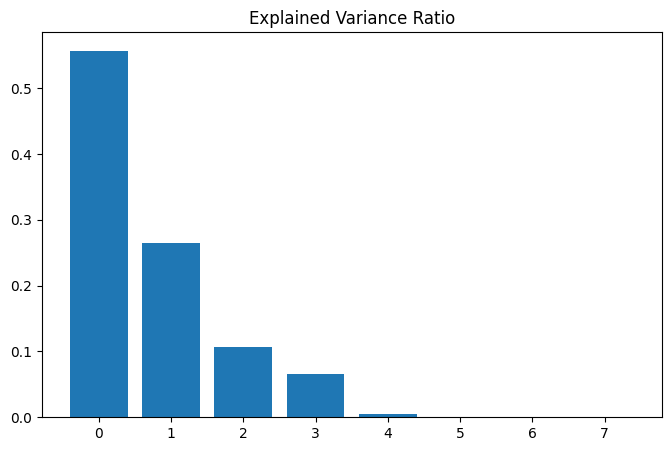

In [ ]:
explained_variance_ratio = eigenvalues / eigenvalues.sum()

plt.figure(figsize=(8,5))
plt.bar(range(len(explained_variance_ratio)), explained_variance_ratio)
plt.title("Explained Variance Ratio")
plt.show()


In [ ]:
cumulative_variance = np.cumsum(explained_variance_ratio)

intrinsic_dim_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Intrinsic Dimension (95% variance):", intrinsic_dim_95)


Intrinsic Dimension (95% variance): 4
